In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from quantile_forest import RandomForestQuantileRegressor

1. Validate on all variables on both ships on model with all parameters
2. Validate on selected variables on both ships no model with only relevant parameters

In [ ]:
X_train = np.load('../../output/data_eagles_vezhen/qrf/X_train.npy')
y_train = np.load('../../output/data_eagles_vezhen/qrf/y_train.npy')
X_test = np.load('../../output/data_eagles_vezhen/qrf/X_test.npy')
y_test = np.load('../../output/data_eagles_vezhen/qrf/y_test.npy')
X_val = np.load('../../output/data_eagles_vezhen/qrf/X_val.npy')
y_val = np.load('../../output/data_eagles_vezhen/qrf/y_val.npy')

SLIDINGW_STEPS = 5
N_OUT_FEATS = y_train.shape[-1]
N_INP_FEATS = X_train.shape[-1]

y_train = y_train.reshape((-1, SLIDINGW_STEPS*N_OUT_FEATS))
X_train = X_train.reshape((-1, SLIDINGW_STEPS*N_INP_FEATS))
y_val = y_val.reshape((-1, SLIDINGW_STEPS*N_OUT_FEATS))
X_val = X_val.reshape((-1, SLIDINGW_STEPS*N_INP_FEATS))
y_test = y_test.reshape((-1, SLIDINGW_STEPS*N_OUT_FEATS))
X_test = X_test.reshape((-1, SLIDINGW_STEPS*N_INP_FEATS))


# Base model with all features

In [6]:
with open('../../output/models/qrf/hyperparam-third.pkl', 'rb+') as f:
    hyperparam_res = pickle.load(f)

hyperparam_res

{(1, 0.5, 0.5, None): [(0.00956053602240816, 0.009782094484324792),
  (0.009343886829679043, 0.009619610784275026),
  (0.00990631883518659, 0.010067781213436237),
  (0.008437575180684135, 0.007891006768179304),
  (0.008299487467513886, 0.008704894049475963)],
 (1, 0.5, 0.5, 4): [(0.011072774654229688, 0.011140520409523642),
  (0.01018325926145913, 0.010514750254256144),
  (0.01096054257103405, 0.011422340720519368),
  (0.008909807613318475, 0.008541086830056048),
  (0.008810799391030837, 0.009208492734685518)],
 (1, 0.5, 0.5, 32): [(0.00951388043871053, 0.009782261601720051),
  (0.00930828317109907, 0.009593807406498267),
  (0.009850820765226856, 0.010074925451776138),
  (0.008403542310911904, 0.007859272770101325),
  (0.008238872053327777, 0.008715363785904989)],
 (1, 0.5, 0.75, None): [(0.009531092348026567, 0.009786013376265997),
  (0.009370626510842552, 0.009580653140235717),
  (0.009922076843445054, 0.010059873970439368),
  (0.008439007767773574, 0.007866817335820847),
  (0.008264

In [7]:
import pandas as pd
df_hyper = pd.DataFrame(hyperparam_res).melt()
df_hyper.columns = ['max_samples_leaf', 'max_features', 'max_samples', 'max_depth', 'value']
df_hyper['loss_low'] = df_hyper['value'].apply(lambda x: x[0])
df_hyper['loss_high'] = df_hyper['value'].apply(lambda x: x[1])
df_hyper.drop(columns=['value'], inplace=True)

In [8]:
df_hyper.groupby('max_samples_leaf')\
    [['loss_low', 'loss_high']]\
    .agg(['mean', 'std'])

loss_low           loss_high          
                      mean       std      mean       std
max_samples_leaf                                        
1                 0.009418  0.000886  0.009571  0.001085
3                 0.009347  0.000787  0.009503  0.001031
5                 0.009310  0.000782  0.009475  0.001020

In [9]:
df_hyper.groupby('max_samples')\
    [['loss_low', 'loss_high']]\
    .agg(['mean', 'std'])

loss_low           loss_high          
                 mean       std      mean       std
max_samples                                        
0.50         0.009334  0.000801  0.009494  0.001018
0.75         0.009362  0.000822  0.009519  0.001054
1.00         0.009380  0.000839  0.009537  0.001067

In [10]:
df_hyper.groupby('max_features')\
    [['loss_low', 'loss_high']]\
    .agg(['mean', 'std'])

loss_low           loss_high          
                  mean       std      mean       std
max_features                                        
0.5           0.009361  0.000835  0.009511  0.001056
0.75          0.009379  0.000841  0.009528  0.001069
sqrt          0.009335  0.000785  0.009511  0.001014

In [11]:
df_hyper.groupby('max_depth', dropna=False)\
    [['loss_low', 'loss_high']]\
    .agg(['mean', 'std'])

loss_low           loss_high          
               mean       std      mean       std
max_depth                                        
4.0        0.009868  0.000895  0.010087  0.001206
32.0       0.009063  0.000663  0.009191  0.000836
NaN        0.009144  0.000621  0.009272  0.000798

In [12]:
best_params = {
    'max_depth': 32,
    'max_samples': 0.5,
    'max_features': 'sqrt',
    'max_samples_leaf': 5,
}

In [13]:
qrf_best = RandomForestQuantileRegressor(**best_params)\
    .fit(X_train, y_train)

In [14]:
y_pred = qrf_best.predict(X_test, quantiles=[0.025, 0.975])
y_low = y_pred[:, :, 0]
y_high = y_pred[:, :, 1]

In [15]:
np.mean( np.abs(y_high - y_low) )

np.float64(0.5306152692802389)

In [16]:
np.mean( (y_test < y_high) & (y_test > y_low) )

np.float64(0.9584699453551913)

In [17]:
y_test =  y_test.reshape((-1,5,3))
y_low = y_low.reshape((-1,5,3))
y_high = y_high.reshape((-1,5,3))
picp_res = np.mean( (y_test < y_high) & (y_test > y_low), axis=0 )
pinaw_res = np.mean( np.abs(y_high - y_low), axis=0 )

In [18]:
df_picp = pd.DataFrame(picp_res, columns=['delta_cog', 'delta_dif', 'dif'])
df_picp['time_step'] = list(range(5,30,5))
df_picp

,delta_cog,delta_dif,dif,time_step
0,0.953513,0.957143,0.971429,5
1,0.954450,0.957143,0.966862,10
2,0.952459,0.957728,0.965105,15
3,0.954684,0.957143,0.961475,20
4,0.955152,0.955621,0.957143,25


In [19]:
df_pinaw = pd.DataFrame(pinaw_res, columns=['delta_cog', 'delta_dif', 'dif'])
df_pinaw['time_step'] = list(range(5,30,5))
df_pinaw

,delta_cog,delta_dif,dif,time_step
0,0.667870,0.418665,0.474140,5
1,0.667215,0.420518,0.486445,10
2,0.674670,0.421622,0.496726,15
3,0.678678,0.423488,0.504422,20
4,0.684261,0.427081,0.513430,25


### TODO: pridet grafiku

In [20]:
y_val_pred = qrf_best.predict(X_val, quantiles=[0.025, 0.975])
y_val_low = y_val_pred[:, :, 0]
y_val_high = y_val_pred[:, :, 1]

val_mmsis = np.load('../../output/data_eagles_vezhen/qrf/val-mmsis.npy', allow_pickle=True)
val_days = np.load('../../output/data_eagles_vezhen/qrf/val-days.npy', allow_pickle=True)

In [21]:
in_pi_mask = (y_val > y_val_low) & (y_val < y_val_high)
in_pi_mask = in_pi_mask.reshape((-1, 5, 3))

In [22]:
group_results = {}
for ix, (mmsi, day) in enumerate(zip(val_mmsis, val_days)):
    
    if (mmsi, day) not in group_results:
        group_results[(mmsi, day)] = [ in_pi_mask[ix, :, :] ]
    else:
        group_results[(mmsi, day)].append( in_pi_mask[ix, :, :] )

In [23]:
df = []

for (mmsi, day), pi_masks in group_results.items():
    means = np.array(pi_masks).mean(axis=1).mean(axis=0)
    df.append({
        'mmsi': mmsi,
        'day': day,
        'delta_cog': means[0],
        'delta_dif': means[1],
        'dif': means[2]
    })

df = pd.DataFrame(df)
df

,mmsi,day,delta_cog,delta_dif,dif
0,305575000,2025-01-22,0.944444,0.940741,0.966667
1,305576000,2025-01-02,0.975862,0.994828,0.989655
2,305576000,2025-01-03,0.912782,0.887218,0.899248
3,305576000,2025-01-04,0.882759,0.935172,0.965517
4,305576000,2025-01-05,0.793103,0.793103,0.868966
...,...,...,...,...,...
78,376846000,2025-01-11,0.979817,0.963303,0.981651
79,376846000,2025-01-12,0.875676,0.805405,0.875676
80,412705880,2025-01-16,0.951872,0.939037,0.915508
81,412705880,2025-01-23,0.990909,0.981818,0.954545


In [24]:
thresh_delta_cog = np.quantile(df['delta_cog'], 0.05)
thresh_delta_dif = np.quantile(df['delta_dif'], 0.05)
thresh_dif = np.quantile(df['dif'], 0.05)

print( 'delta_cog limit:', np.quantile(df['delta_cog'], 0.05) )
print( 'delta_dif liimt:', np.quantile(df['delta_dif'], 0.05) )
print( 'dif liimt:', np.quantile(df['dif'], 0.05) )

delta_cog limit: 0.8760028449502135
delta_dif liimt: 0.883721804511278
dif liimt: 0.8726739505462908


In [25]:
in_pi_mask = (y_test > y_low) & (y_test < y_high)
in_pi_mask = in_pi_mask.reshape((-1, 5, 3))

test_mmsis = np.load('../../output/data_eagles_vezhen/test-mmsis.npy', allow_pickle=True)
test_days = np.load('../../output/data_eagles_vezhen/test-days.npy', allow_pickle=True)

In [26]:
group_results = {}
for ix, (mmsi, day) in enumerate(zip(test_mmsis, test_days)):
    
    if (mmsi, day) not in group_results:
        group_results[(mmsi, day)] = [ in_pi_mask[ix, :, :] ]
    else:
        group_results[(mmsi, day)].append( in_pi_mask[ix, :, :] )

In [27]:
df = []

for (mmsi, day), pi_masks in group_results.items():
    means = np.array(pi_masks).mean(axis=1).mean(axis=0)
    df.append({
        'mmsi': mmsi,
        'day': day,
        'delta_cog': means[0],
        'delta_dif': means[1],
        'dif': means[2]
    })

df = pd.DataFrame(df)

In [28]:
(df['delta_cog'] < thresh_delta_cog).mean()

np.float64(0.01282051282051282)

In [29]:
(df['dif'] < thresh_dif).mean()

np.float64(0.0)

In [30]:
(df['delta_dif'] < thresh_delta_dif).mean()

np.float64(0.038461538461538464)

In [40]:
vezhen_y = np.load('../../output/data_eagles_vezhen/qrf/vezhen_y.npy', allow_pickle=True)\
    .reshape((-1, 5*3))
vezhen_x = np.load('../../output/data_eagles_vezhen/qrf/vezhen_x.npy', allow_pickle=True)\
    .reshape((-1, 5*20))
eagles_y = np.load('../../output/data_eagles_vezhen/qrf/eagles_y.npy', allow_pickle=True)\
    .reshape((-1, 5*3))
eagles_x = np.load('../../output/data_eagles_vezhen/qrf/eagles_x.npy', allow_pickle=True)\
    .reshape((-1, 5*20))

In [41]:
eagles_model_out = qrf_best.predict(eagles_x, quantiles=[0.025, 0.975])
eagles_low, eagles_high = eagles_model_out[:, :, 0], eagles_model_out[:, :, 1]

In [42]:
eagles_low = eagles_low.reshape((eagles_low.shape[0], 5, 3))
eagles_high = eagles_high.reshape((eagles_high.shape[0], 5, 3))

cog_delta_eagles_low = eagles_low[:, 1, 0]
cog_delta_eagles_high = eagles_high[:, 1, 0]

delta_dif_eagles_low = eagles_low[:, 1, 1]
delta_dif_eagles_high = eagles_high[:, 1, 1]

dif_eagles_low = eagles_low[:, 1, 2]
dif_eagles_high = eagles_high[:, 1, 2]

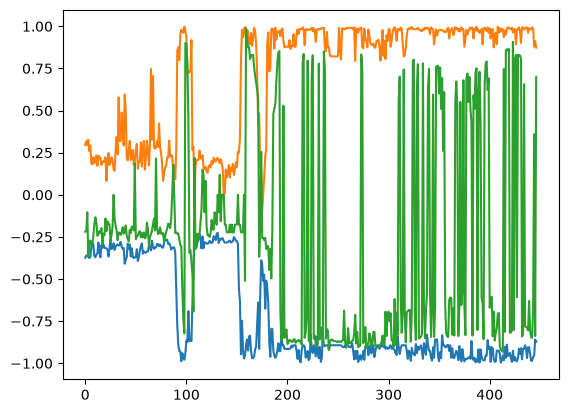

In [43]:
plt.plot(dif_eagles_low)
plt.plot(dif_eagles_high)
plt.plot(eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 2])

In [44]:
np.mean( (
    (dif_eagles_low < eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 2]) &
    (dif_eagles_high > eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 2])
) )

np.float64(0.9485458612975392)

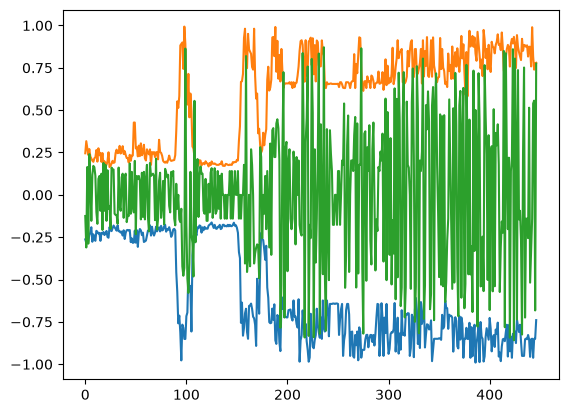

In [45]:
plt.plot(delta_dif_eagles_low)
plt.plot(delta_dif_eagles_high)
plt.plot(eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 1])

In [46]:
np.mean( (
    (delta_dif_eagles_low < eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 1]) &
    (delta_dif_eagles_high > eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 1])
) )

np.float64(0.9328859060402684)

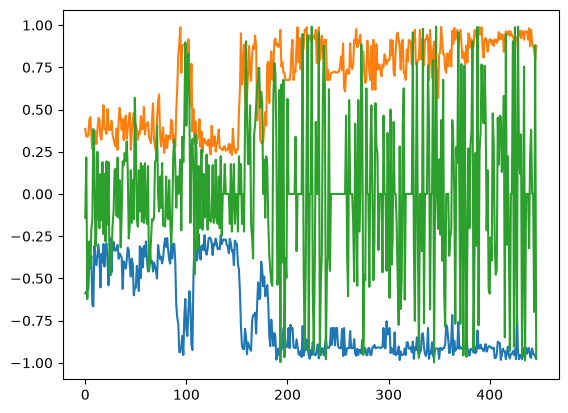

In [47]:
plt.plot(cog_delta_eagles_low)
plt.plot(cog_delta_eagles_high)
plt.plot(eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 0])

In [48]:
np.mean( (
    (cog_delta_eagles_low < eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 0]) &
    (cog_delta_eagles_high > eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 0])
) )

np.float64(0.9060402684563759)

In [50]:
vezhen_model_out = qrf_best.predict(vezhen_x, quantiles=[0.025, 0.975])
vezhen_low, vezhen_high = vezhen_model_out[:, :, 0], vezhen_model_out[:, :, 1]

In [52]:
vezhen_low = vezhen_low.reshape((vezhen_low.shape[0], 5, 3))
vezhen_high = vezhen_high.reshape((vezhen_high.shape[0], 5, 3))

cog_delta_vezhen_low = vezhen_low[:, 0, 0]
cog_delta_vezhen_high = vezhen_high[:, 0, 0]

delta_dif_vezhen_low = vezhen_low[:, 0, 1]
delta_dif_vezhen_high = vezhen_high[:, 0, 1]

dif_vezhen_low = vezhen_low[:, 0, 2]
dif_vezhen_high = vezhen_high[:, 0, 2]

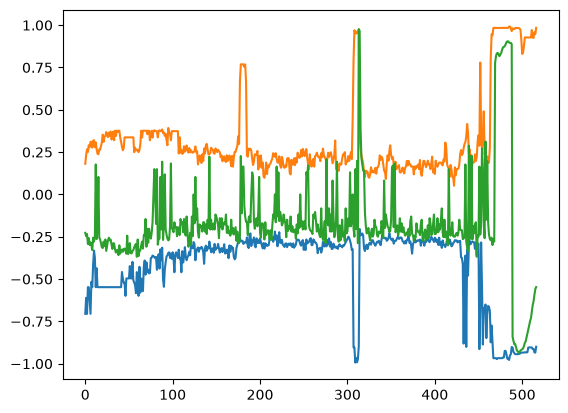

In [53]:
plt.plot(dif_vezhen_low)
plt.plot(dif_vezhen_high)
plt.plot(vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 2])

In [54]:
np.mean( (
    (dif_vezhen_low < vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 2]) &
    (dif_vezhen_high > vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 2])
) )

np.float64(0.9632495164410058)

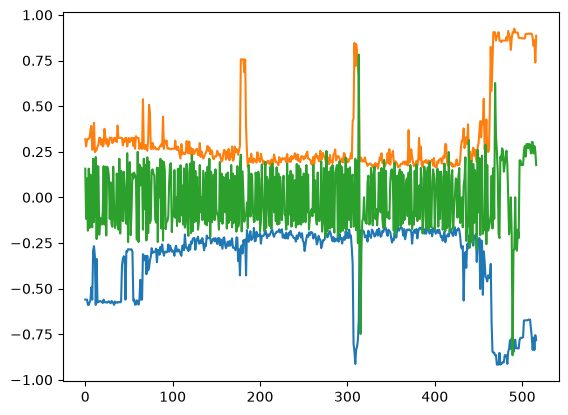

In [55]:
plt.plot(delta_dif_vezhen_low)
plt.plot(delta_dif_vezhen_high)
plt.plot(vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 1])

In [56]:
np.mean( (
    (delta_dif_vezhen_low < vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 1]) &
    (delta_dif_vezhen_high > vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 1])
) )

np.float64(0.9555125725338491)

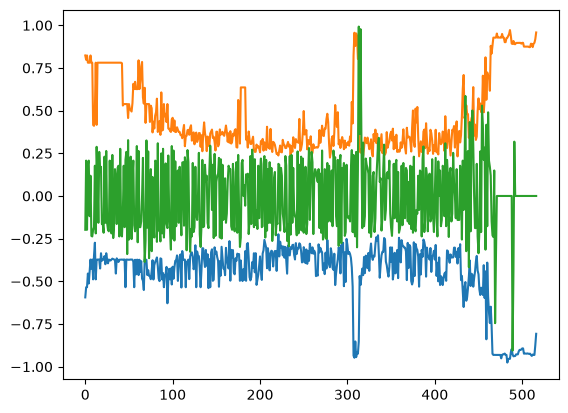

In [57]:
plt.plot(cog_delta_vezhen_low)
plt.plot(cog_delta_vezhen_high)
plt.plot(vezhen_y[:, 0])

In [58]:
np.mean( (
    (cog_delta_vezhen_low < vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 0]) &
    (cog_delta_vezhen_high > vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 0])
) )

np.float64(0.9729206963249516)

# Base model with only selected features

In [59]:
with open('../../output/models/qrf/qrf-featcounts-loss.pkl', 'rb+') as f:
    feat_counts = pickle.load(f)
with open('../../output/models/qrf/qrf-remove-features.pkl', 'rb+') as f:
    rm_feats = pickle.load(f)

In [60]:
import seaborn as sns

Text(0, 0.5, 'Loss')

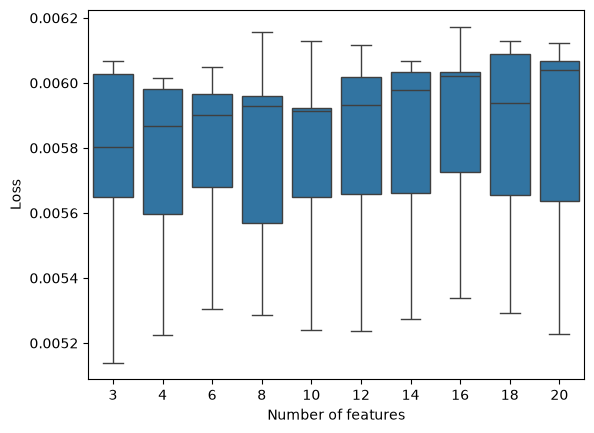

In [71]:
df_featcounts_loss = pd.DataFrame(feat_counts).melt()

df_featcounts_loss['variable'] = 20-df_featcounts_loss['variable']

sns.boxplot(
    data=df_featcounts_loss,
    x='variable',
    y='value'
)

plt.xlabel('Number of features')
plt.ylabel('Loss')

In [72]:
df = pd.read_csv('../../output/data_eagles_vezhen/df-prepared-eagle.csv')
df.drop(columns=['day', 'MMSI']).columns

Index(['SPEED', 'COURSE', 'currentSpeed', 'gust', 'swellHeight', 'waveHeight',
       'windSpeed', 'dif', 'COURSE_vec_x', 'COURSE_vec_y',
       'currentDirection_vec_x', 'currentDirection_vec_y',
       'swellDirection_vec_x', 'swellDirection_vec_y', 'waveDirection_vec_x',
       'waveDirection_vec_y', 'windDirection_vec_x', 'windDirection_vec_y',
       'COURSE-dif', 'delta_dif'],
      dtype='str')

In [73]:
rm_feats

[np.int64(6),
 np.int64(3),
 np.int64(2),
 np.int64(5),
 np.int64(4),
 np.int64(14),
 np.int64(1),
 np.int64(15),
 np.int64(13),
 np.int64(12),
 np.int64(11),
 np.int64(17),
 np.int64(0),
 np.int64(16),
 np.int64(10),
 np.int64(8),
 np.int64(9),
 np.int64(19)]

In [61]:
X_train_sel = X_train\
    .reshape((-1, 5, 20))\
    [:, :, [7, 18, 19]]\
    .reshape((-1, 5*3))

qrf_best = RandomForestQuantileRegressor(**best_params)\
    .fit(X_train_sel, y_train)

In [68]:
vezhen_x_sel = vezhen_x\
    .reshape((-1, 5, 20))\
    [:, :, [7, 18, 19]]\
    .reshape((-1, 5*3))

vezhen_model_out = qrf_best.predict(vezhen_x_sel, quantiles=[0.025, 0.975])
vezhen_low, vezhen_high = vezhen_model_out[:, :, 0], vezhen_model_out[:, :, 1]

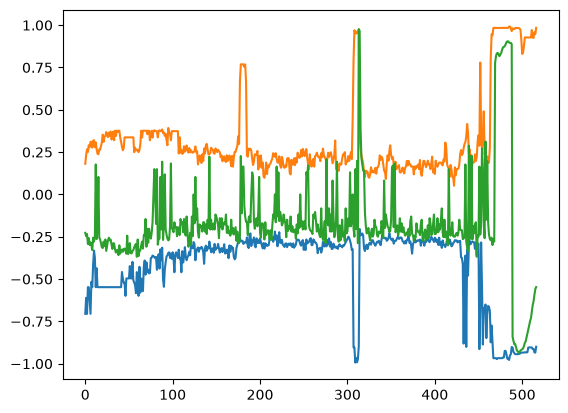

In [69]:
plt.plot(dif_vezhen_low)
plt.plot(dif_vezhen_high)
plt.plot(vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 2])

In [70]:
np.mean( (
    (dif_vezhen_low < vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 2]) &
    (dif_vezhen_high > vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 2])
) )

np.float64(0.9632495164410058)

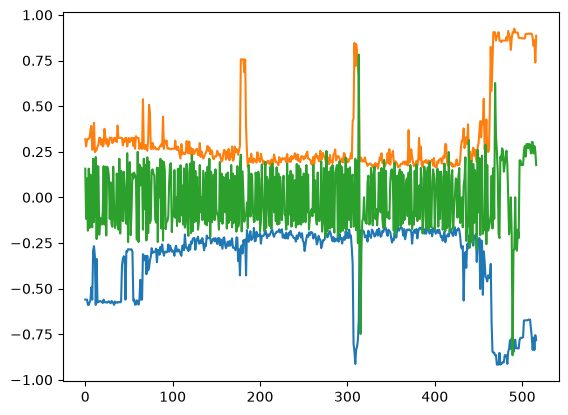

In [71]:
plt.plot(delta_dif_vezhen_low)
plt.plot(delta_dif_vezhen_high)
plt.plot(vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 1])

In [72]:
np.mean( (
    (delta_dif_vezhen_low < vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 1]) &
    (delta_dif_vezhen_high > vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 1])
) )

np.float64(0.9555125725338491)

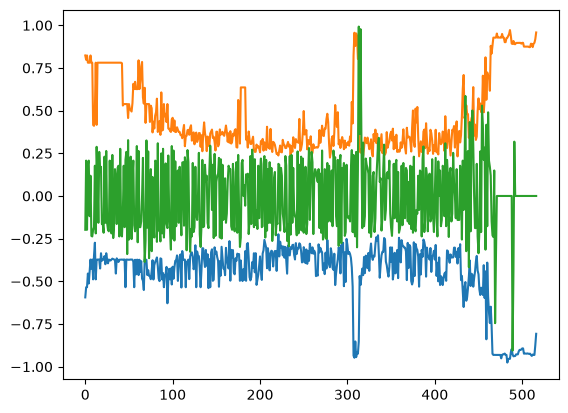

In [73]:
plt.plot(cog_delta_vezhen_low)
plt.plot(cog_delta_vezhen_high)
plt.plot(vezhen_y[:, 0])

In [74]:
np.mean( (
    (cog_delta_vezhen_low < vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 0]) &
    (cog_delta_vezhen_high > vezhen_y.reshape(vezhen_y.shape[0], 5, 3)[:, 0, 0])
) )

np.float64(0.9729206963249516)

In [75]:
eagles_x = eagles_x\
    .reshape((-1, 5, 20))\
    [:, :, [7, 18, 19]]\
    .reshape((-1, 5*3))

eagles_model_out = qrf_best.predict(eagles_x, quantiles=[0.025, 0.975])
eagles_low, eagles_high = eagles_model_out[:, :, 0], eagles_model_out[:, :, 1]

In [76]:
eagles_low = eagles_low.reshape((eagles_low.shape[0], 5, 3))
eagles_high = eagles_high.reshape((eagles_high.shape[0], 5, 3))

cog_delta_eagles_low = eagles_low[:, 0, 0]
cog_delta_eagles_high = eagles_high[:, 0, 0]

delta_dif_eagles_low = eagles_low[:, 0, 1]
delta_dif_eagles_high = eagles_high[:, 0, 1]

dif_eagles_low = eagles_low[:, 0, 2]
dif_eagles_high = eagles_high[:, 0, 2]

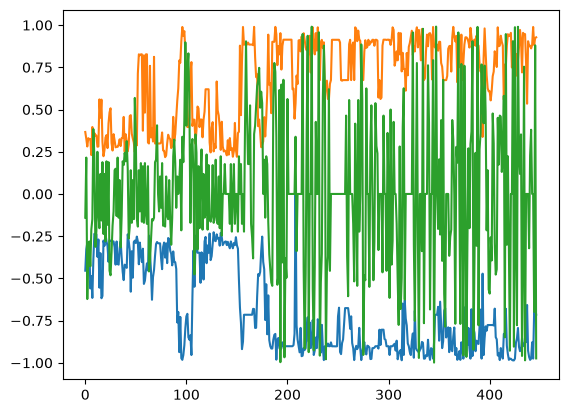

In [77]:
plt.plot(cog_delta_eagles_low)
plt.plot(cog_delta_eagles_high)
plt.plot(eagles_y[:, 0])

In [78]:
np.mean( (
    (cog_delta_eagles_low < eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 0]) &
    (cog_delta_eagles_high > eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 0])
) )

np.float64(0.8590604026845637)

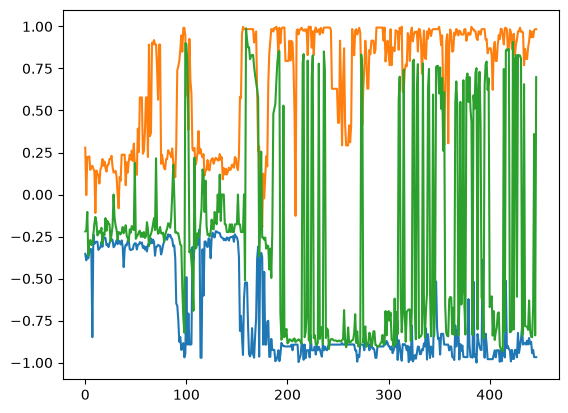

In [79]:
plt.plot(dif_eagles_low)
plt.plot(dif_eagles_high)
plt.plot(eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 2])

In [80]:
np.mean( (
    (dif_eagles_low < eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 2]) &
    (dif_eagles_high > eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 2])
) )

np.float64(0.9105145413870246)

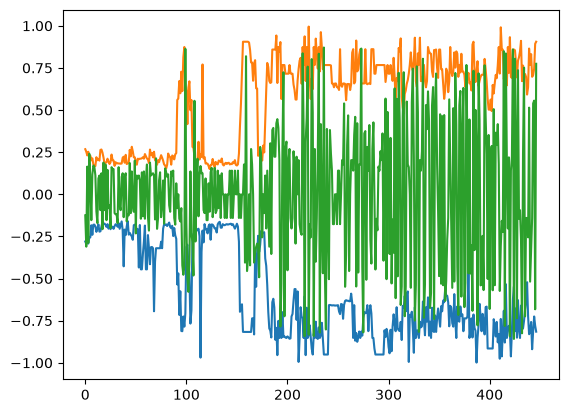

In [81]:
plt.plot(delta_dif_eagles_low)
plt.plot(delta_dif_eagles_high)
plt.plot(eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 1])

In [82]:
np.mean( (
    (delta_dif_eagles_low < eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 1]) &
    (delta_dif_eagles_high > eagles_y.reshape(eagles_y.shape[0], 5, 3)[:, 0, 1])
) )

np.float64(0.9038031319910514)